# Model Architecture Visualization

A concise notebook to visualize model architectures using torchviz.

In [5]:
import torch
import sys
import os
from torchviz import make_dot

# Add models directory to path
models_dir = os.path.join(os.getcwd(), "models")
if models_dir not in sys.path:
    sys.path.append(models_dir)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## LSTM Self-Attention Model

Let's create and visualize the LSTM model with self-attention.

In [6]:
# Define model parameters
VOCAB_SIZE = 49152
EMBEDDING_SIZE = 4096
LSTM_NODES = 256
OUTPUT_DIM = 50

# Define the model class
class LSTMClassifier(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers,
                 batch_first, bidirectional, dropout, pretrained_weights=None):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim).to(device)
        self.rnn = torch.nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=bidirectional, dropout=dropout, 
                            batch_first=batch_first).to(device)
        self.fc = torch.nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim).to(device)
        self.dropout = torch.nn.Dropout(dropout).to(device)
        self.attention = torch.nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, 1).to(device)
        
        # Initialize with pretrained weights if available
        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights).to(device)

    def forward(self, text):
        text = text.to(device)
        if text.dim() == 3:
            batch_size, sentence_length, num_sentences = text.size()
            text = text.view(batch_size, -1)
        
        embedded = self.dropout(self.embedding(text))
        lstm_output, (hidden, _) = self.rnn(embedded)
        attention_weights = torch.softmax(self.attention(lstm_output), dim=1)
        attended_output = torch.sum(lstm_output * attention_weights, dim=1)
        output = self.fc(self.dropout(attended_output))
        output = torch.sigmoid(output)
        return output

# Create random weights for visualization
pretrained_weights = torch.randn(VOCAB_SIZE, EMBEDDING_SIZE).to(device)

# Instantiate model
lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_SIZE,
    hidden_dim=LSTM_NODES,
    output_dim=OUTPUT_DIM,
    n_layers=2,
    batch_first=True,
    bidirectional=True,
    dropout=0.5,
    pretrained_weights=pretrained_weights
).to(device)

print(lstm_model)

LSTMClassifier(
  (embedding): Embedding(49152, 4096)
  (rnn): LSTM(4096, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=50, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (attention): Linear(in_features=512, out_features=1, bias=True)
)


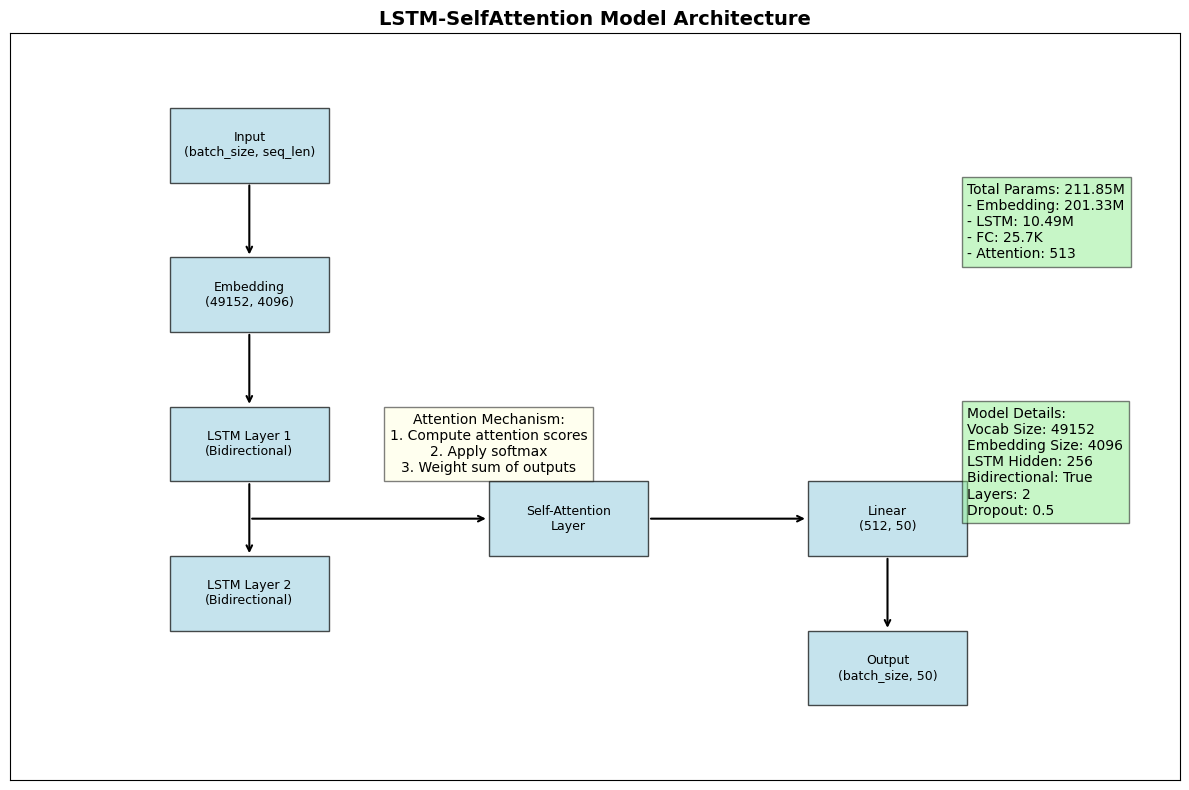

Architecture diagram saved as lstm_self_attention_diagram.png


In [17]:
# Create a manual visualization of the LSTM-SelfAttention architecture
# This will show the data flow more clearly
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def create_architecture_diagram(save_path="lstm_self_attention_diagram.png"):
    """Create a manual diagram of the LSTM-SelfAttention architecture"""
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Component coordinates and sizes
    comps = {
        "input": {"pos": (0.1, 0.8), "width": 0.15, "height": 0.1, "label": "Input\n(batch_size, seq_len)"},
        "embedding": {"pos": (0.1, 0.6), "width": 0.15, "height": 0.1, "label": f"Embedding\n({VOCAB_SIZE}, {EMBEDDING_SIZE})"},
        "lstm1": {"pos": (0.1, 0.4), "width": 0.15, "height": 0.1, "label": "LSTM Layer 1\n(Bidirectional)"},
        "lstm2": {"pos": (0.1, 0.2), "width": 0.15, "height": 0.1, "label": "LSTM Layer 2\n(Bidirectional)"},
        "attention": {"pos": (0.4, 0.3), "width": 0.15, "height": 0.1, "label": "Self-Attention\nLayer"},
        "fc": {"pos": (0.7, 0.3), "width": 0.15, "height": 0.1, "label": f"Linear\n({LSTM_NODES*2}, {OUTPUT_DIM})"},
        "output": {"pos": (0.7, 0.1), "width": 0.15, "height": 0.1, "label": "Output\n(batch_size, 50)"}
    }
    
    # Draw boxes for each component
    for comp_name, comp in comps.items():
        rect = patches.Rectangle(comp["pos"], comp["width"], comp["height"], 
                                linewidth=1, edgecolor='black', facecolor='lightblue', alpha=0.7)
        ax.add_patch(rect)
        ax.text(comp["pos"][0] + comp["width"]/2, comp["pos"][1] + comp["height"]/2,
               comp["label"], ha='center', va='center', fontsize=9)
    
    # Draw arrows for connections
    arrows = [
        ("input", "embedding"),
        ("embedding", "lstm1"),
        ("lstm1", "lstm2"),
        ("lstm2", "attention"),
        ("attention", "fc"),
        ("fc", "output")
    ]
    
    for start, end in arrows:
        start_pos = (comps[start]["pos"][0] + comps[start]["width"]/2, 
                    comps[start]["pos"][1])
        
        if end == "attention":
            # Special case for lstm2 -> attention (horizontal arrow)
            end_pos = (comps[end]["pos"][0], 
                      comps[end]["pos"][1] + comps[end]["height"]/2)
            ax.annotate("", xy=end_pos, xytext=(start_pos[0], end_pos[1]),
                       arrowprops=dict(arrowstyle="->", lw=1.5))
        elif start == "attention":
            # Special case for attention -> fc (horizontal arrow)
            start_pos = (comps[start]["pos"][0] + comps[start]["width"], 
                        comps[start]["pos"][1] + comps[start]["height"]/2)
            end_pos = (comps[end]["pos"][0], 
                      comps[end]["pos"][1] + comps[end]["height"]/2)
            ax.annotate("", xy=end_pos, xytext=start_pos,
                       arrowprops=dict(arrowstyle="->", lw=1.5))
        elif start == "fc":
            # Special case for fc -> output (vertical arrow)
            start_pos = (comps[start]["pos"][0] + comps[start]["width"]/2, 
                        comps[start]["pos"][1])
            end_pos = (comps[end]["pos"][0] + comps[end]["width"]/2, 
                      comps[end]["pos"][1] + comps[end]["height"])
            ax.annotate("", xy=end_pos, xytext=start_pos,
                       arrowprops=dict(arrowstyle="->", lw=1.5))
        else:
            # Default vertical arrow
            end_pos = (comps[end]["pos"][0] + comps[end]["width"]/2, 
                      comps[end]["pos"][1] + comps[end]["height"])
            ax.annotate("", xy=end_pos, xytext=start_pos,
                       arrowprops=dict(arrowstyle="->", lw=1.5))
    
    # Add attention mechanism details
    ax.text(0.4, 0.45, "Attention Mechanism:\n1. Compute attention scores\n2. Apply softmax\n3. Weight sum of outputs", 
            ha='center', va='center', bbox=dict(facecolor='lightyellow', alpha=0.5))
    
    # Add parameter count information
    params_text = (
        f"Total Params: 211.85M\n"
        f"- Embedding: 201.33M\n"
        f"- LSTM: 10.49M\n"
        f"- FC: 25.7K\n"
        f"- Attention: 513"
    )
    ax.text(0.85, 0.8, params_text, ha='left', va='top', 
            bbox=dict(facecolor='lightgreen', alpha=0.5))
    
    # Add model details
    ax.text(0.85, 0.5, 
            f"Model Details:\n"
            f"Vocab Size: {VOCAB_SIZE}\n"
            f"Embedding Size: {EMBEDDING_SIZE}\n"
            f"LSTM Hidden: {LSTM_NODES}\n"
            f"Bidirectional: True\n"
            f"Layers: 2\n"
            f"Dropout: 0.5",
            ha='left', va='top', bbox=dict(facecolor='lightgreen', alpha=0.5))
    
    # Add title
    ax.set_title("LSTM-SelfAttention Model Architecture", fontsize=14, fontweight='bold')
    
    # Remove axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Set axis limits
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1)
    
    # Save the diagram
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Architecture diagram saved as {save_path}")

# Create the architecture diagram
create_architecture_diagram()

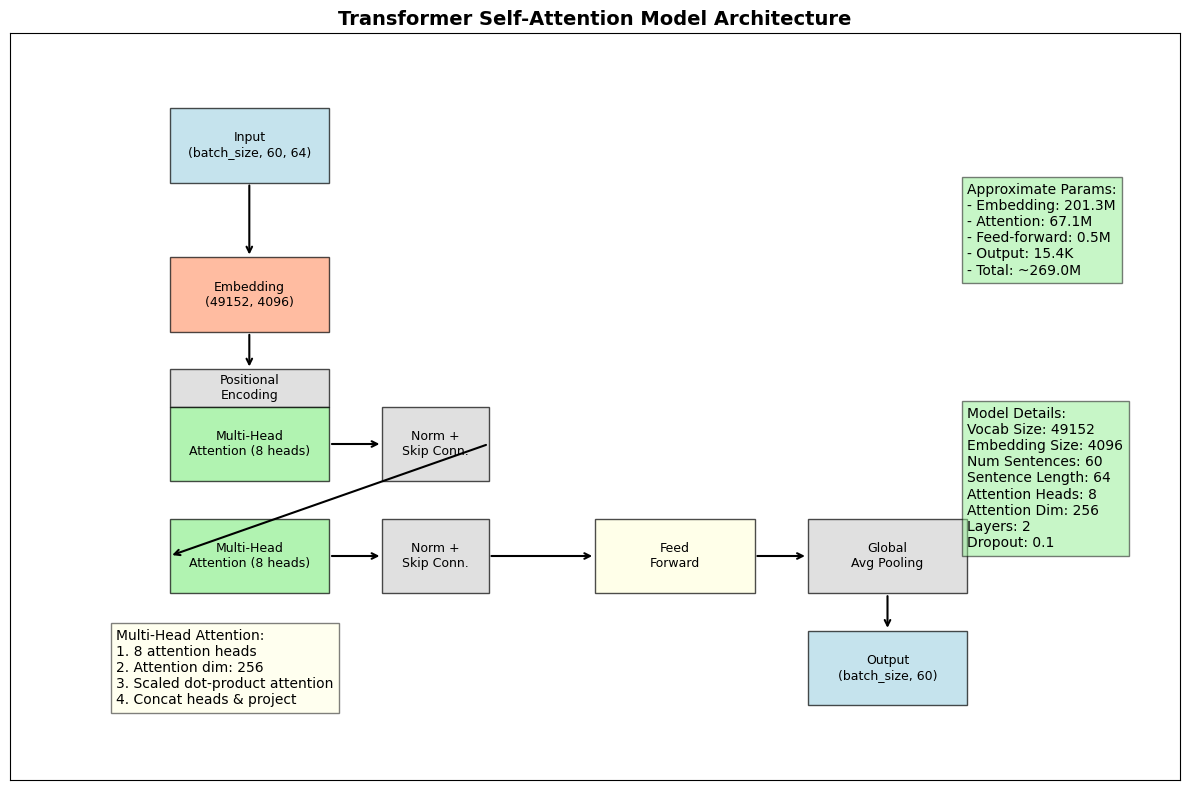

Transformer architecture diagram saved as transformer_self_attention_diagram.png


In [16]:
def create_transformer_diagram(save_path="transformer_self_attention_diagram.png"):
    """Create a manual diagram of the Transformer-SelfAttention architecture"""
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Update model parameters based on run_models.py
    NUM_SENTENCES = 60
    SENTENCE_LENGTH = 64
    ATTENTION_DIM = 256
    ATTENTION_HEADS = 8
    
    # Define the transformer architecture components
    comps = {
        "input": {"pos": (0.1, 0.8), "width": 0.15, "height": 0.1, "label": f"Input\n(batch_size, {NUM_SENTENCES}, {SENTENCE_LENGTH})"},
        "embedding": {"pos": (0.1, 0.6), "width": 0.15, "height": 0.1, "label": f"Embedding\n({VOCAB_SIZE}, {EMBEDDING_SIZE})"},
        "pos_encoding": {"pos": (0.1, 0.5), "width": 0.15, "height": 0.05, "label": "Positional\nEncoding"},
        "attn1": {"pos": (0.1, 0.4), "width": 0.15, "height": 0.1, "label": f"Multi-Head\nAttention ({ATTENTION_HEADS} heads)"},
        "norm1": {"pos": (0.3, 0.4), "width": 0.1, "height": 0.1, "label": "Norm +\nSkip Conn."},
        "attn2": {"pos": (0.1, 0.25), "width": 0.15, "height": 0.1, "label": f"Multi-Head\nAttention ({ATTENTION_HEADS} heads)"},
        "norm2": {"pos": (0.3, 0.25), "width": 0.1, "height": 0.1, "label": "Norm +\nSkip Conn."},
        "feedfwd": {"pos": (0.5, 0.25), "width": 0.15, "height": 0.1, "label": "Feed\nForward"},
        "pooling": {"pos": (0.7, 0.25), "width": 0.15, "height": 0.1, "label": "Global\nAvg Pooling"},
        "output": {"pos": (0.7, 0.1), "width": 0.15, "height": 0.1, "label": f"Output\n(batch_size, {NUM_SENTENCES})"}
    }
    
    # Draw boxes for each component
    for comp_name, comp in comps.items():
        if 'attn' in comp_name:
            color = 'lightgreen'
        elif comp_name == 'embedding':
            color = 'lightsalmon'
        elif comp_name in ['input', 'output']:
            color = 'lightblue'
        elif comp_name == 'feedfwd':
            color = 'lightyellow'
        else:
            color = 'lightgray'
            
        rect = patches.Rectangle(comp["pos"], comp["width"], comp["height"], 
                                linewidth=1, edgecolor='black', facecolor=color, alpha=0.7)
        ax.add_patch(rect)
        ax.text(comp["pos"][0] + comp["width"]/2, comp["pos"][1] + comp["height"]/2,
               comp["label"], ha='center', va='center', fontsize=9)
    
    # Draw arrows for main connections
    arrows = [
        ("input", "embedding"),
        ("embedding", "pos_encoding"),
        ("pos_encoding", "attn1"),
        ("attn1", "norm1"),
        ("norm1", "attn2"),
        ("attn2", "norm2"),
        ("norm2", "feedfwd"),
        ("feedfwd", "pooling"),
        ("pooling", "output")
    ]
    
    for start, end in arrows:
        if start == "attn1" or start == "attn2":
            # Horizontal arrows for attention blocks
            start_pos = (comps[start]["pos"][0] + comps[start]["width"], 
                        comps[start]["pos"][1] + comps[start]["height"]/2)
            end_pos = (comps[end]["pos"][0], 
                      comps[end]["pos"][1] + comps[end]["height"]/2)
        elif start == "norm1" or start == "norm2" or start == "feedfwd":
            # Horizontal arrows for norm and feedforward
            start_pos = (comps[start]["pos"][0] + comps[start]["width"], 
                        comps[start]["pos"][1] + comps[start]["height"]/2)
            end_pos = (comps[end]["pos"][0], 
                      comps[end]["pos"][1] + comps[end]["height"]/2)
        elif end == "output":
            # Vertical arrow to output
            start_pos = (comps[start]["pos"][0] + comps[start]["width"]/2, 
                        comps[start]["pos"][1])
            end_pos = (comps[end]["pos"][0] + comps[end]["width"]/2, 
                      comps[end]["pos"][1] + comps[end]["height"])
        else:
            # Default vertical arrows
            start_pos = (comps[start]["pos"][0] + comps[start]["width"]/2, 
                        comps[start]["pos"][1])
            end_pos = (comps[end]["pos"][0] + comps[end]["width"]/2, 
                      comps[end]["pos"][1] + comps[end]["height"])
        
        ax.annotate("", xy=end_pos, xytext=start_pos,
                   arrowprops=dict(arrowstyle="->", lw=1.5))
    
    # Add multi-head attention detail
    ax.text(0.05, 0.15, 
            "Multi-Head Attention:\n"
            f"1. {ATTENTION_HEADS} attention heads\n"
            f"2. Attention dim: {ATTENTION_DIM}\n"
            "3. Scaled dot-product attention\n"
            "4. Concat heads & project",
            ha='left', va='center', bbox=dict(facecolor='lightyellow', alpha=0.5))
    
    # Add parameter count information
    embedding_params = VOCAB_SIZE * EMBEDDING_SIZE
    attention_params_approx = 4 * ATTENTION_DIM * EMBEDDING_SIZE * ATTENTION_HEADS * 2  # Approximation for both attention blocks
    ff_params_approx = 2 * ATTENTION_DIM * ATTENTION_DIM * 4  # Feed-forward expansion factor typically 4x
    output_params = ATTENTION_DIM * NUM_SENTENCES
    
    params_text = (
        f"Approximate Params:\n"
        f"- Embedding: {embedding_params/1e6:.1f}M\n"
        f"- Attention: {attention_params_approx/1e6:.1f}M\n" 
        f"- Feed-forward: {ff_params_approx/1e6:.1f}M\n"
        f"- Output: {output_params/1e3:.1f}K\n"
        f"- Total: ~{(embedding_params + attention_params_approx + ff_params_approx + output_params)/1e6:.1f}M"
    )
    ax.text(0.85, 0.8, params_text, ha='left', va='top', 
            bbox=dict(facecolor='lightgreen', alpha=0.5))
    
    # Add model details
    ax.text(0.85, 0.5, 
            f"Model Details:\n"
            f"Vocab Size: {VOCAB_SIZE}\n"
            f"Embedding Size: {EMBEDDING_SIZE}\n"
            f"Num Sentences: {NUM_SENTENCES}\n"
            f"Sentence Length: {SENTENCE_LENGTH}\n"
            f"Attention Heads: {ATTENTION_HEADS}\n"
            f"Attention Dim: {ATTENTION_DIM}\n"
            f"Layers: 2\n"
            f"Dropout: 0.1",
            ha='left', va='top', bbox=dict(facecolor='lightgreen', alpha=0.5))
    
    # Add title
    ax.set_title("Transformer Self-Attention Model Architecture", fontsize=14, fontweight='bold')
    
    # Remove axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Set axis limits
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1)
    
    # Save the diagram
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Transformer architecture diagram saved as {save_path}")

create_transformer_diagram()